In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet

# Clean veri dizini tespiti
if os.path.exists(os.path.join("Data", "Clean")):
  clean_path = os.path.join("Data", "Clean")
elif os.path.exists(os.path.join("..", "Data", "Clean")):
  clean_path = os.path.join("..", "Data", "Clean")
else:
  clean_path = os.path.join("..", "..", "Data", "Clean")

# Master veriyi yüklüyoruz
df = pd.read_csv(os.path.join(clean_path, "master_orders_clean.csv"))
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

print(f"✔ Veri Yüklendi: {len(df):,} Satır\n")

#  GÜNLÜK SATIŞ VERİSİNİN HAZIRLANMASI
# Prophet kütüphanesi strictly 'ds' (tarih) ve 'y' (satış tutarı) sütun isimleri bekler
daily_sales = (
    df.groupby(df["order_purchase_timestamp"].dt.date)["total_price"]
    .sum()
    .reset_index()
)
daily_sales.columns = ["ds", "y"]
daily_sales["ds"] = pd.to_datetime(daily_sales["ds"])

#  PROPHET MODELİNİN EĞİTİLMESİ VE 30 GÜNLÜK TAHMİN
model = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False
)
model.fit(daily_sales)

# Önümüzdeki 30 günün tarihlerini oluşturup tahmin yaptıralım
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

print(" Prophet 30 Günlük Satış Tahmin Modeli Başarıyla Eğitildi!")

c:\Users\Betül Bağcı\OneDrive\Desktop\EcommerceAnalytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✔ Veri Yüklendi: 112,650 Satır



15:03:50 - cmdstanpy - INFO - Chain [1] start processing
15:03:50 - cmdstanpy - INFO - Chain [1] done processing


 Prophet 30 Günlük Satış Tahmin Modeli Başarıyla Eğitildi!


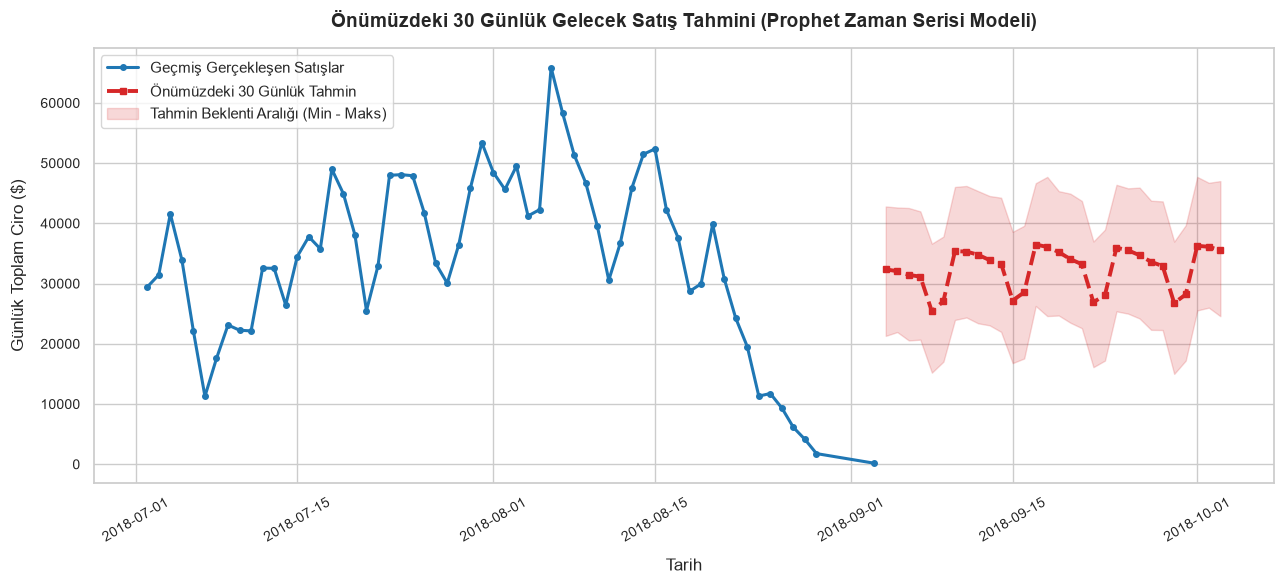

In [2]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

#  Son 60 günün gerçekleşen satışı ile önümüzdeki 30 günün tahminini ayıralım
historical_recent = daily_sales.tail(60)
forecast_future = forecast.tail(30)

plt.figure(figsize=(13, 6))

#  Geçmiş Gerçekleşen Satışlar (Mavi Çizgi)
plt.plot(
    historical_recent["ds"],
    historical_recent["y"],
    label="Geçmiş Gerçekleşen Satışlar",
    color="#1f77b4",
    linewidth=2.2,
    marker="o",
    markersize=4,
)

#  Önümüzdeki 30 Günlük Gelecek Tahmini (Kırmızı Kesikli Çizgi)
plt.plot(
    forecast_future["ds"],
    forecast_future["yhat"],
    label="Önümüzdeki 30 Günlük Tahmin",
    color="#d62728",
    linewidth=2.8,
    linestyle="--",
    marker="s",
    markersize=5,
)

#  Tahmin Güven Aralığı (Açık Kırmızı Gölgelendirme)
plt.fill_between(
    forecast_future["ds"],
    forecast_future["yhat_lower"],
    forecast_future["yhat_upper"],
    color="#d62728",
    alpha=0.18,
    label="Tahmin Beklenti Aralığı (Min - Maks)",
)

# Grafiği Şık ve Anlaşılır Hale Getirme
plt.title(
    "Önümüzdeki 30 Günlük Gelecek Satış Tahmini (Prophet Zaman Serisi"
    " Modeli)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Tarih", fontsize=12, labelpad=10)
plt.ylabel("Günlük Toplam Ciro ($)", fontsize=12, labelpad=10)
plt.xticks(rotation=30, fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc="upper left", fontsize=11, frameon=True)
plt.tight_layout()
plt.show()